# Cepheid Period-Luminosity Calibration

The provided dataset contains results of a simulated observational campaign aimed at calibrating the period-luminosity relation for Cepheid variables. The relation is assumed to take the form:

$$M = a [\log_{10}(P) - 1] + b.$$

The dataset is a database of observations stored as a PDF table. The data has been partly corrupted, so not all rows contain all data — discard incomplete rows and use only those where a galaxy spectrum, an estimated Cepheid period, and its mean apparent magnitude are all available.

Assume that the redshift of a Cepheid in a galaxy equals the redshift of the whole galaxy due to cosmological expansion. Assume the validity of Hubble's law in the form:

$$v_{\text{rec}} = H_0 \cdot d$$

across the whole provided dataset, with $H_0 = 67\\,\text{km}\\,\text{s}^{-1}\\,\text{Mpc}^{-1}$. Estimate galaxy redshifts using template cross-correlation in log-$\lambda$ space. Since the redshifts are small, assume the classical formula for the redshift. The laboratory reference spectrum is provided together with the dataset.

Produce the following outputs:

1. A PDF table with two columns — one listing Cepheids ordered by their ID and the other showing the estimated redshifts to 5 decimal places.
2. A plot of the data points used for the fit, including the best-fit straight line motivated by the period-luminosity relation.
3. A TXT file clearly stating the estimated fit parameters with uncertainties derived from the linear regression.
________________________________________

Import necessary dependencies used in the data generation and data processing pipeline.

In [14]:
import numpy as np
import random
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
import os
import shutil
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.signal import correlate
from collections import defaultdict
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

This is where you can set all the parameters of the simulation and data generation.

- **N_GALAXIES** : Number of galaxies to generate in the table
- **Z_MAX** : Maximal value of the redshift in the dataset
- **SIGMA_DISTANCE_CEPHEID** : Introduces spread in the distances of Cepheids. We don't want all datapoints be exactly on the line $v = H_0 d$
- **CEPHEID_GENERATE_PROBABILITY** : Not all generated galaxies in the table have Cepheid. This is the probability that galaxy entry has also Cepheid entry.
- **SPECTRUM_GENERATE_PROBABILITY** : Not all galaxies have measured spectra. This influences how many observed spectra images we will have (~ N_GALAXIES * SPECTRUM_GENERATE_PROBABILITY)
- **READING_PRECISION** : Basically reading error in nm. This rounds peak position to the closest integer multiple of reading precision step.

In [15]:
# Set paths and create clean folders for spectra
path = "./"
os.chdir(path)
spectra_folder = 'input_data/observed_spectra'
shutil.rmtree(spectra_folder)
os.makedirs(spectra_folder)

# Physics constants and parameters
c = 299792.458 #km/s
H = 67 #km/s/Mpc

# Simulation parameters
N_GALAXIES = 20
Z_MAX = 0.05
SIGMA_DISTANCE_CEPHEIDES = 0.1
CEPHEID_GENERATE_PROBABILITY = 0.5
SPECTRUM_GENERATE_PROBABILITY = 0.5
READING_PRECISION = 0.2 #nm

# Laboratory spectrum with 20 known most prominent lines in the spectrum (400-750nm) 
# Based on NIST Atomic Spectra Database
LAMBDA_MIN = 400.0 #nm
LAMBDA_MAX = 750.0 #nm
LAB_SPECTRUM = {656.3: 1.0, 500.7: 0.9, 589.0: 0.85, 589.6: 0.8, 486.1: 0.75, 495.9: 0.65, 
                587.6: 0.6, 658.3: 0.55, 654.8: 0.5, 434.0: 0.45, 671.6: 0.38, 673.1: 0.34, 
                410.2: 0.3, 667.8: 0.27, 630.0: 0.23, 518.4: 0.2, 447.1: 0.17, 422.7: 0.15, 
                636.4: 0.12, 438.3: 0.1}

Data generation pipeline.

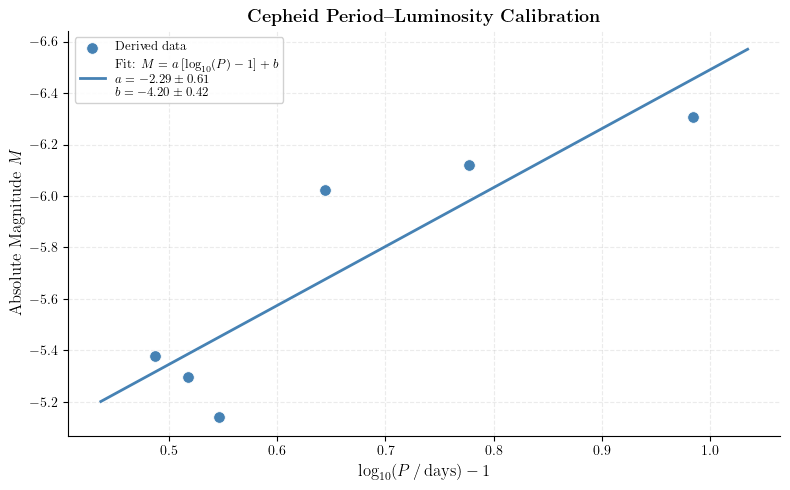

Slope:     -2.292 ± 0.609  (canonical: -2.43)
Intercept: -4.199 ± 0.415  (canonical: -4.05)


In [16]:

############################################################
################ Dataframe format
############################################################

df = pd.DataFrame({ 'index': pd.Series(dtype='int'),
                    'galaxy_ID': pd.Series(dtype='str'),
                    'z' : pd.Series(dtype='float'),
                    'spectrum' : pd.Series(dtype='object'),
                    'true_distance [pc]' : pd.Series(dtype='float'),
                    'cepheid_ID': pd.Series(dtype='str'),
                    'cepheid_distance [pc]' : pd.Series(dtype='float'),
                    'mean_mag_cepheid': pd.Series(dtype='float'),
                    'period [days]': pd.Series(dtype='float'),
                    'z_estimated' : pd.Series(dtype='float'),
                    'sigma_z_estimated' : pd.Series(dtype='float'),
                    'z_allowed_interval' : pd.Series(dtype='str'),
                    'distance_estimated [pc]' : pd.Series(dtype='float'),
                    'absolute_mag_estimated' : pd.Series(dtype='float')})


############################################################
################ Function to produce graphical spectra
############################################################

def plot_spectrum(input_spectrum: dict[float, float], title: str = '', name: str = '', save_to: str = path+spectra_folder) -> None:
    def gaussian(x, mu, sigma, amplitude):
        return amplitude * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

    wavelength = np.linspace(LAMBDA_MIN, LAMBDA_MAX, 7000)
    intensity = np.zeros_like(wavelength)
    for mu, amp in input_spectrum.items():
        intensity += gaussian(wavelength, mu, sigma=0.1, amplitude=amp)
    intensity /= intensity.max()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(wavelength, intensity, color='white', linewidth=0.8)
    ax.fill_between(wavelength, intensity, alpha=0.4, color='cyan')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')

    ax.set_title(title, color='white')
    ax.set_xlabel("Wavelength (nm)", color='white')
    ax.set_ylabel("Relative Intensity", color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.tick_params(axis='x', which='major', length=8, colors='white')
    ax.tick_params(axis='x', which='minor', length=4, colors='white')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}' if x % 50 == 0 else ''))

    ax.set_xlim(400, 750)
    ax.set_ylim(0, 1.05)

    plt.tight_layout()
    #plt.show()
    plt.savefig(f"{save_to}/{name}.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()


plot_spectrum(LAB_SPECTRUM, f'Spectrum from the laboratory ({int(LAMBDA_MIN)} - {int(LAMBDA_MAX)} nm)', "spectral_lines_lab", save_to=path + "/input_data")


############################################################
################ Function simulating reading error
############################################################

def apply_reading_error(spectrum: dict, resolution: float = READING_PRECISION) -> dict:
    """Round wavelengths to nearest multiple of `resolution` nm.
    If two lines collide, keep the brighter one (or sum them — see comment)."""
    rounded = defaultdict(float)
    for wl, amp in spectrum.items():
        key = round(wl / resolution) * resolution
        rounded[key] = max(rounded[key], amp)   # or: rounded[key] += amp to sum
    return dict(rounded)


############################################################
### Function doing the spectral lines fit - cross-correlation 
### in log space. Also returns estimated error of the fit.
############################################################

def estimate_z_logspace(observed_spectrum: dict, lab_spectrum: dict,
                         wav_min=LAMBDA_MIN, wav_max=LAMBDA_MAX, n_pts=7000) -> tuple[float, float]:
    log_wav = np.linspace(np.log(wav_min), np.log(wav_max), n_pts)

    def make_intensity_log(spectrum):
        inten = np.zeros(n_pts)
        for mu, amp in spectrum.items():
            log_mu = np.log(mu)
            inten += amp * np.exp(-(log_wav - log_mu)**2 / (2 * 0.0003**2))
        return inten / inten.max()

    lab_inten = make_intensity_log(apply_reading_error(lab_spectrum))
    obs_inten = make_intensity_log(apply_reading_error(observed_spectrum))

    corr = correlate(obs_inten, lab_inten, mode='full')
    lags = np.arange(-(n_pts - 1), n_pts)
    best_idx = np.argmax(corr)
    best_lag = lags[best_idx]

    # Fit parabola around the peak using 5 neighbouring points
    half_w = 5
    idx_lo = max(best_idx - half_w, 0)
    idx_hi = min(best_idx + half_w + 1, len(corr))
    local_lags = lags[idx_lo:idx_hi]
    local_corr = corr[idx_lo:idx_hi]
    coeffs = np.polyfit(local_lags, local_corr, 2)   # a*x^2 + b*x + c
    # Peak of parabola at x = -b/2a, width ~ 1/sqrt(-a)
    a_coeff = coeffs[0]
    sigma_lag = 1.0 / np.sqrt(-a_coeff) if a_coeff < 0 else np.nan

    log_wav_per_sample = (np.log(wav_max) - np.log(wav_min)) / n_pts
    delta_log_wav       = best_lag * log_wav_per_sample
    sigma_log_wav       = sigma_lag * log_wav_per_sample

    z      = np.exp(delta_log_wav) - 1 # z = e^(Δlog λ) - 1
    sigma_z = np.exp(delta_log_wav) * sigma_log_wav   # error propagation

    return z, sigma_z

############################################################
################ Loop to generate data files
############################################################

for i in range(N_GALAXIES):
    random.seed(42 + i)
    np.random.seed(42 + i)
    index = i
    galaxy_ID = 'G_' + ''.join(random.choices(string.digits, k=8))

    if np.random.uniform(0,1) < SPECTRUM_GENERATE_PROBABILITY:
        z = random.uniform(0.2,1)*Z_MAX
        LINE_VISIBLE_PROBABILITY = 0.5
        spectrum = {}
        for line in LAB_SPECTRUM.keys():
            shifted_line = line * (z + 1)
            if random.uniform(0,1) < LINE_VISIBLE_PROBABILITY:
                spectrum[shifted_line] = LAB_SPECTRUM[line]
        plot_spectrum(spectrum, f"Observed spectrum - {galaxy_ID}", galaxy_ID, path + spectra_folder)
    else:
        z = np.nan
        spectrum = {}

    true_distance = float(z*c/H * 10**6)
    if np.random.uniform(0,1) < CEPHEID_GENERATE_PROBABILITY:
        cepheid_ID = 'CEPH_' + ''.join(random.choices(string.digits, k=8))
        cepheid_distance = np.random.normal(loc=true_distance, scale=true_distance*SIGMA_DISTANCE_CEPHEIDES) #pc
        period = abs(np.random.normal(loc=60, scale=20))
        if not np.isnan(true_distance):
            mean_mag = -2.43*(math.log10(period) - 1) - 4.05 - 5 + 5*math.log10(cepheid_distance)
        else:
            # This is dirty trick to confuse model when I merge some cells in the csv table  and gives some unrealistic
            #  values of magnitude in the table (while not being so obvious), which can propagate to the result if the table
            # is not parsed correctly. These values are only for cepheids without redshift information, so they don't matter
            # for the analysis.
            mean_mag = -2.43*(math.log10(period * (1 + np.random.normal(loc=0, scale=0.3)) + 15) - 1) - 4.05 - 5 + 5*math.log10(cepheid_distance) + np.random.normal(loc=2, scale=2)
    else:
        cepheid_ID = np.nan
        cepheid_distance = np.nan
        period = np.nan
        mean_mag = np.nan

    if not np.isnan(z) and spectrum:
        estimated_z, sigma_z = estimate_z_logspace(spectrum, LAB_SPECTRUM, wav_min=LAMBDA_MIN, wav_max=LAMBDA_MAX, n_pts=7000)
        distance_estimated = estimated_z * c / H * 10**6
        interval = f"[{z-0.0001:.5f}; {z+0.0001:.5f}]"
    else:
        estimated_z = np.nan
        sigma_z = np.nan
        distance_estimated = np.nan
        interval = np.nan

    if not np.isnan(mean_mag) and not np.isnan(distance_estimated) and distance_estimated > 0:
        absolute_mag_estimated = mean_mag + 5 - 5 * math.log10(distance_estimated)
    else:
        absolute_mag_estimated = np.nan

    # Fill the dataframe with the row of generated data
    new_row = pd.DataFrame([{'index' : index,
                             'galaxy_ID' : galaxy_ID,
                             'z' : z,
                             'spectrum' : spectrum,
                             'true_distance [pc]' : true_distance,
                             'cepheid_ID' : cepheid_ID,
                             'cepheid_distance [pc]' : cepheid_distance,
                             'mean_mag_cepheid' : mean_mag,
                             'period [days]' : period,
                             'z_estimated': estimated_z,
                             'sigma_z_estimated': sigma_z,
                             'z_allowed_interval' : interval,
                             'distance_estimated [pc]' : distance_estimated,
                             'absolute_mag_estimated' : absolute_mag_estimated}])
    
    df = pd.concat([df, new_row], ignore_index=True)


############################################################
################ Prepare input data
############################################################

# Print data that can be estimated
df_est = df.copy()
df_est['z'] = df['z'].round(4)
df_est['mean_mag_cepheid'] = df['mean_mag_cepheid'].round(3)
df_est['period [days]'] = df['period [days]'].round(4)

# Print cepheides to .csv file (for human parsing)
df_out = df_est.copy()
df_out['mean_mag_cepheid']                    = df_est['mean_mag_cepheid'].map('{:.3f}'.format)
df_out['period [days]'] = df_est['period [days]'].map('{:.4f}'.format)
df_out[['galaxy_ID' , 'cepheid_ID', 'mean_mag_cepheid', 'period [days]']].to_csv(path + "/input_data" + "/cepheides_measurements.csv", index=False)

# Big PDF can be challenging for some models to parse
df_pdf = df_out[['galaxy_ID', 'cepheid_ID', 'mean_mag_cepheid', 'period [days]']].copy()

with PdfPages(path + "/input_data" + "/cepheides_measurements.pdf") as pdf:
    # Split into chunks if table is large (max ~40 rows per page looks good)
    rows_per_page = 40
    chunks = [df_pdf[i:i+rows_per_page] for i in range(0, len(df_pdf), rows_per_page)]
    
    for chunk in chunks:
        fig, ax = plt.subplots(figsize=(8, len(chunk) * 0.3 + 1))
        ax.axis('off')
        table = ax.table(
            cellText=chunk.values,
            colLabels=chunk.columns,
            cellLoc='center',
            loc='center'
        )
        table.auto_set_font_size(True)
        table.scale(1, 1.4)
        for (row, col), cell in table.get_celld().items():
            if row == 0:
                cell.set_text_props(fontweight='bold')
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()


############################################################
################ Plot graph - solution
############################################################

# Collect fit data
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
df_fit = df[df['period [days]'].notna() & df['absolute_mag_estimated'].notna()].copy()
df_fit['logP_m1'] = np.log10(df_fit['period [days]']) - 1

x = df_fit['logP_m1'].values
y = df_fit['absolute_mag_estimated'].values

slope, intercept, r_value, _, _ = stats.linregress(x, y)

# Uncertainty estimates
n   = len(x)
y_pred    = slope * x + intercept
s2        = np.sum((y - y_pred)**2) / (n - 2)
sxx       = np.sum((x - x.mean())**2)
se_slope  = np.sqrt(s2 / sxx)
se_inter  = np.sqrt(s2 * (1/n + x.mean()**2 / sxx))

# Plot
x_line = np.linspace(x.min() - 0.05, x.max() + 0.05, 300)

fig, ax = plt.subplots(figsize=(8, 5))

# Data points
ax.scatter(x, y, color='steelblue', s=70, zorder=3,
           edgecolors='white', linewidths=0.6, label='Derived data')

# Fitted line
fit_label = (
    f'Fit:  $M = a\\,[\\log_{{10}}(P) - 1] + b$\n'
    f'$a = {slope:.2f} \\pm {se_slope:.2f}$\n'
    f'$b = {intercept:.2f} \\pm {se_inter:.2f}$'
)

ax.plot(x_line, slope * x_line + intercept,
        color='steelblue', lw=2, label=fit_label)

# Axes & styling
ax.invert_yaxis()   # brighter = smaller M = top of plot
ax.set_xlabel(r'$\log_{10}(P\,/\,\mathrm{days}) - 1$', fontsize=12)
ax.set_ylabel(r'Absolute Magnitude $M$', fontsize=12)
ax.set_title('\\textbf{Cepheid Period–Luminosity Calibration}', fontsize=13, fontweight='bold')

ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
ax.grid(True, alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(path + "/golden_truth/" + "cepheids_calibration.png", dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()


############################################################
################ Output estimated redshifts pdf - solution
############################################################

df_filtered = df_out.loc[df_out['cepheid_ID'].notna() & df_out['mean_mag_cepheid'].notna() & df_out['period [days]'].notna() & df_out['z_estimated'].notna()].copy()
df_filtered.sort_values(by='cepheid_ID', ascending=True, inplace=True)
df_out_pdf = df_filtered[['cepheid_ID', 'z_estimated']].reset_index(drop=True)
df_out_pdf['z_estimated'] = df_out_pdf['z_estimated'].map('{:.5f}'.format)

with PdfPages(path + "/golden_truth/redshifts.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(6, len(df_out_pdf) * 0.3 + 1))
    ax.axis('off')
    table = ax.table(
        cellText=df_out_pdf.values,
        colLabels=['\\textbf{Cepheid ID}', '\\textbf{Redshift}'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(True)
    table.scale(1, 1.4)
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # header row
            cell.set_text_props(fontweight='bold')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()


############################################################
################ Output txt report - solution
############################################################

a_str = f"a = {slope:.3f} ± {se_slope:.3f}"
b_str = f"b = {intercept:.3f} ± {se_inter:.3f}"
width = max(len(a_str), len(b_str)) + 4

box = (
    f"┌{'─' * width}┐\n"
    f"│  {a_str:<{width-2}}│\n"
    f"│  {b_str:<{width-2}}│\n"
    f"└{'─' * width}┘"
)

with open(path + '/golden_truth/cepheid_period-luminosity.txt', 'w') as f:
    print(
        f'We assumed the period-luminosity calibration for Cepheid variables\n'
        f'in form M = a[log(P) - 1] + b.\n\n'
        f'Parameters estimated by our analysis are:\n\n'
        f'{box}',
        file=f
    )


############################################################
################ Estimated parameters for quick check - solution
############################################################

print(f"Slope:     {slope:.3f} ± {se_slope:.3f}  (canonical: -2.43)")
print(f"Intercept: {intercept:.3f} ± {se_inter:.3f}  (canonical: -4.05)")



Save the dataframe with intermediate results for future inspection and display data plotted in the graph.

In [17]:
# Save dataframe for potential further analysis
df.to_pickle("./golden_truth/dataframe.pkl")

# Print estimated redshifts for quick check
df[['cepheid_ID', 'z', 'z_estimated', 'sigma_z_estimated', 'z_allowed_interval']].dropna().sort_values('cepheid_ID')

,cepheid_ID,z,z_estimated,sigma_z_estimated,z_allowed_interval
12,CEPH_20871297,0.025284,0.025371,0.000281,[0.02518; 0.02538]
18,CEPH_22919928,0.044385,0.044422,0.000184,[0.04428; 0.04448]
15,CEPH_35298324,0.045359,0.045454,0.000242,[0.04526; 0.04546]
7,CEPH_70253422,0.016174,0.016204,0.000195,[0.01607; 0.01627]
16,CEPH_91417222,0.045077,0.045079,0.000176,[0.04498; 0.04518]
8,CEPH_97192642,0.037058,0.037132,0.000197,[0.03696; 0.03716]
